# Gradio Semantic Mask Segmentation Demo
* Author: Juan Pablo Triana Martinez
* Date: 2026-04-19

This notebook creates a live **semantic** segmentation demo using Gradio.

### Note
**A trained `.pth` semantic model must exist before running this notebook.**

The demo will:
1. Accept an input image (preferably a document page).
2. Transform the image to match the training pipeline.
3. Predict a **12-class semantic mask** (class 0 = background, classes 1-11 = DocLayNet supercategories).
4. If a ground-truth mask is provided, compute `get_semantic_metrics` (hard pixel) and `get_soft_metrics` (soft region).
5. Overlay the colour-coded predicted mask on the original image.

## 1. Imports and paths

In [13]:
from pathlib import Path
import sys
import torch
from torchvision import transforms
from typing import Dict

# Resolve the project root and add it to the module search path
working_path = Path().cwd().parent
sys.path.insert(0, str(working_path))

In [14]:
DATA_PATH = working_path / "data"
SUBSET_DATANAME = "doclaynet_20_percent_seed_7"

# Empirical mean/std from 20% of the DocLayNet dataset (same as training)
mean = [0.9329, 0.9343, 0.9341]
std  = [0.1651, 0.1592, 0.1623]
new_height = 512
new_width  = 512

# Inference transform: resize + normalise (no augmentation)
inference_transform = transforms.Compose([
    transforms.Resize((new_height, new_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# Raw transform used only to convert GT mask PIL -> tensor (no normalisation)
api_transform = transforms.Compose([
    transforms.Resize((new_height, new_width)),
    transforms.ToTensor(),
])

## 2. Load the semantic model

In [15]:
from src.models import LinknetModel

MODEL_NAME = "linknet_semantic_doclaynet_20_percent_seed_7_ce_0.25_dice_1.0_.pth"
model_path = working_path / "models" / MODEL_NAME
print(f"Model path exists: {model_path.exists()}")

Model path exists: True


In [16]:
# 12 output channels: class 0 = background, classes 1-11 = DocLayNet supercategories
NUM_CLASSES = 12

# Force CPU for portability (HuggingFace Spaces / local demo)
device = "cpu"
semantic_model = LinknetModel(Cin=3, N=NUM_CLASSES).to(device)
semantic_model.load_state_dict(torch.load(f=model_path, map_location=device))
semantic_model.eval()
print("Semantic model loaded successfully.")

Semantic model loaded successfully.


## 3. Build the class index → name mapping

In [17]:
from src.utils import MetadataRetriever

metadata_retriever = MetadataRetriever(
    data_path=DATA_PATH,
    dataset_name=SUBSET_DATANAME,
    split_analyze="train",
)

supercategories = metadata_retriever.get_metadata_supercategories()

# Class 0 = background (no annotation)
CLASS_ID_TO_NAME: Dict[int, str] = {0: "background"}
for cat in supercategories:
    CLASS_ID_TO_NAME[cat["id"]] = cat.get("supercategory", cat["name"])

print("Class index → name mapping:")
for idx, name in sorted(CLASS_ID_TO_NAME.items()):
    print(f"  [{idx:2d}] {name}")

Class index → name mapping:
  [ 0] background
  [ 1] Caption
  [ 2] Footnote
  [ 3] Formula
  [ 4] List-item
  [ 5] Page-footer
  [ 6] Page-header
  [ 7] Picture
  [ 8] Section-header
  [ 9] Table
  [10] Text
  [11] Title


## 4. Retrieve a sample image and mask for reference

In [18]:
from src.data import TextDetectionDataset

text_detection_dataset = TextDetectionDataset(
    data_path=DATA_PATH,
    split_analyze="test",
    dataset_name=SUBSET_DATANAME,
    mask_type="semantic-layout",
    new_height=new_height,
    new_width=new_width,
    transform=None,
)

test_img, test_mask, test_img_metadata = text_detection_dataset[14]
print(f"Image input shape:  {test_img.shape}")
print(f"Semantic mask shape: {test_mask.shape}, dtype: {test_mask.dtype}")
print(f"Image metadata: {test_img_metadata}")

Image input shape:  torch.Size([3, 512, 512])
Semantic mask shape: torch.Size([512, 512]), dtype: torch.int64
Image metadata: {'id': 4052, 'width': 512, 'height': 512, 'file_name': 'a52fa0c9339f9038e76f8ca424adf6a610083523de9925d6e5f7ba1ee6618bb0.png', 'collection': 'manuals', 'doc_name': 'IBM-i-s5445349.pdf', 'page_no': 438, 'precedence': 0, 'doc_category': 'manuals'}


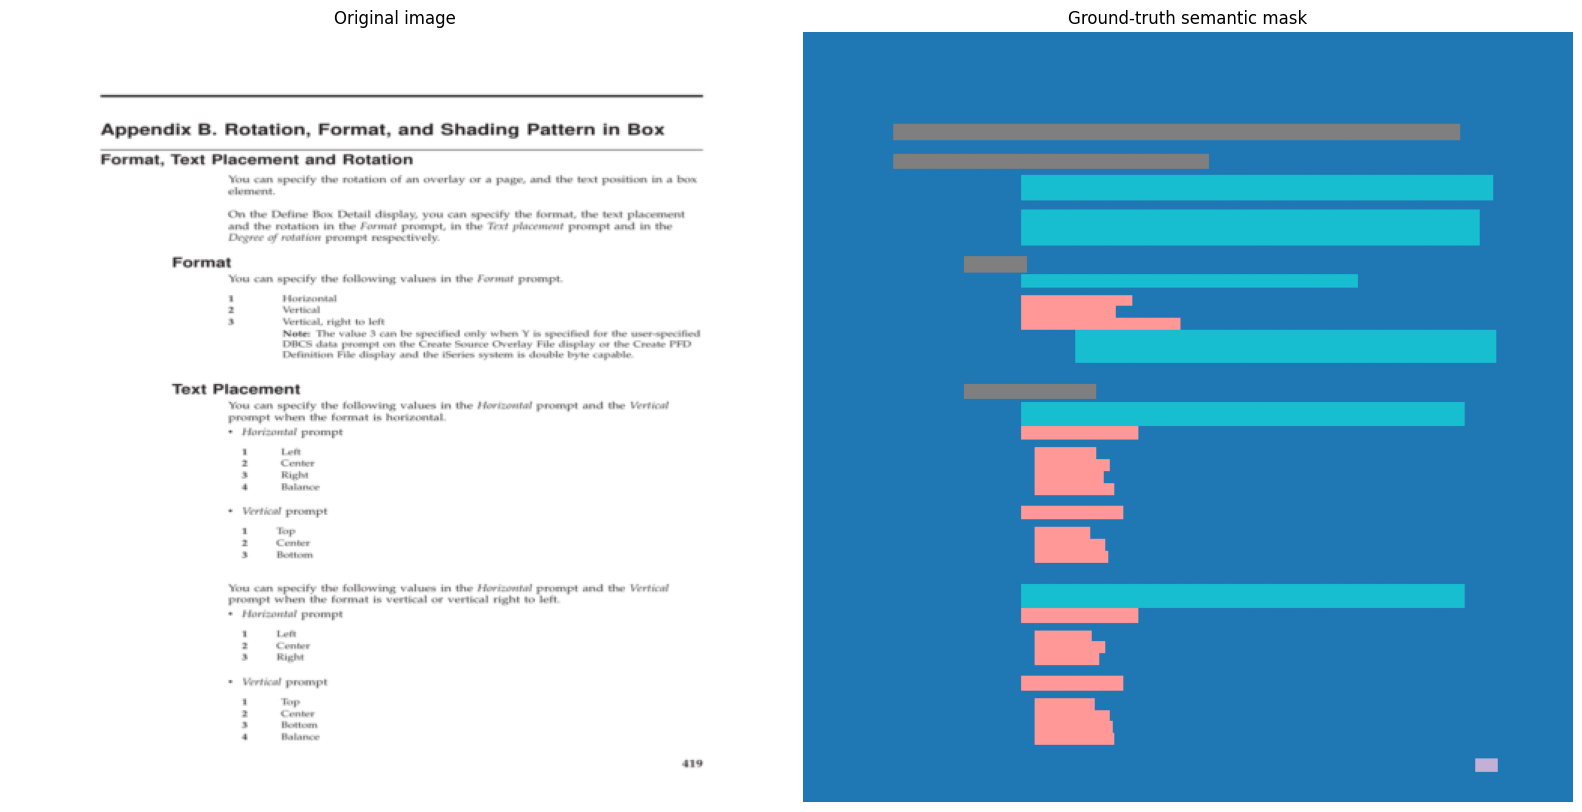

In [19]:
import matplotlib.pyplot as plt
import numpy as np


def build_class_colormap(num_classes: int) -> np.ndarray:
    """Return an (num_classes, 3) float array using matplotlib tab20."""
    cmap = plt.get_cmap("tab20", num_classes)
    return np.array([cmap(i)[:3] for i in range(num_classes)])


def apply_colormap(mask_hw: np.ndarray, color_lut: np.ndarray) -> np.ndarray:
    """Convert an (H, W) integer class mask to an (H, W, 3) RGB image."""
    H, W = mask_hw.shape
    rgb = np.zeros((H, W, 3), dtype=np.float32)
    for c in range(color_lut.shape[0]):
        rgb[mask_hw == c] = color_lut[c]
    return rgb


COLOR_LUT = build_class_colormap(NUM_CLASSES)

img_np  = test_img.permute(1, 2, 0).cpu().numpy()
mask_hw = test_mask.squeeze().cpu().numpy().astype(np.int32)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title("Original image")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(apply_colormap(mask_hw, COLOR_LUT))
plt.title("Ground-truth semantic mask")
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Save sample images for demo examples

In [20]:
import os
from PIL import Image


def save_img_and_semantic_mask_separately(
        img_tensor: torch.Tensor,
        mask_tensor: torch.Tensor,
        save_dir: Path,
        filename: str,
        num_classes: int = 12,
):
    """
    Save image and colour-coded semantic mask separately as PNG files.

    Args:
        img_tensor:  Shape [C, H, W], values in [0, 1].
        mask_tensor: Shape [H, W] or [1, H, W], integer class indices.
        save_dir:    Directory to save files.
        filename:    Base filename (no extension).
        num_classes: Total number of classes (for colormap).
    """
    save_dir.mkdir(parents=True, exist_ok=True)

    # Convert image
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    else:
        img_np = img_np.astype(np.uint8)

    # Convert semantic mask -> colour-coded RGB PNG
    mask_hw = mask_tensor.squeeze().cpu().numpy().astype(np.int32)
    color_lut = build_class_colormap(num_classes)
    mask_rgb  = (apply_colormap(mask_hw, color_lut) * 255).astype(np.uint8)

    img_path  = os.path.join(save_dir, f"{filename}_img.png")
    mask_path = os.path.join(save_dir, f"{filename}_semantic_mask.png")

    Image.fromarray(img_np).save(img_path)
    Image.fromarray(mask_rgb).save(mask_path)

    return img_path, mask_path

In [21]:
save_dir_demo = working_path / "demo"
img_path_saved, mask_path_saved = save_img_and_semantic_mask_separately(
    img_tensor=test_img,
    mask_tensor=test_mask,
    save_dir=save_dir_demo,
    filename="semantic_3",
    num_classes=NUM_CLASSES,
)
print(f"Saved image : {img_path_saved}")
print(f"Saved mask  : {mask_path_saved}")

Saved image : c:\Users\ajedr\Documents\Masters_Post_Cert_AI_Stanford_USD_2023_2026\AAI_590_Machine_Learning_Capstone\AAI-590-OCR-Master\demo\semantic_3_img.png
Saved mask  : c:\Users\ajedr\Documents\Masters_Post_Cert_AI_Stanford_USD_2023_2026\AAI_590_Machine_Learning_Capstone\AAI-590-OCR-Master\demo\semantic_3_semantic_mask.png


## 6. Test single-image prediction

[INFO] Prediction on image at path: c:\Users\ajedr\Documents\Masters_Post_Cert_AI_Stanford_USD_2023_2026\AAI_590_Machine_Learning_Capstone\AAI-590-OCR-Master\data\doclaynet_20_percent_seed_7\PNG\669d42c0001f9418de666047b25dc194f965b4118a96a439f87aaecefc1e6aef.png


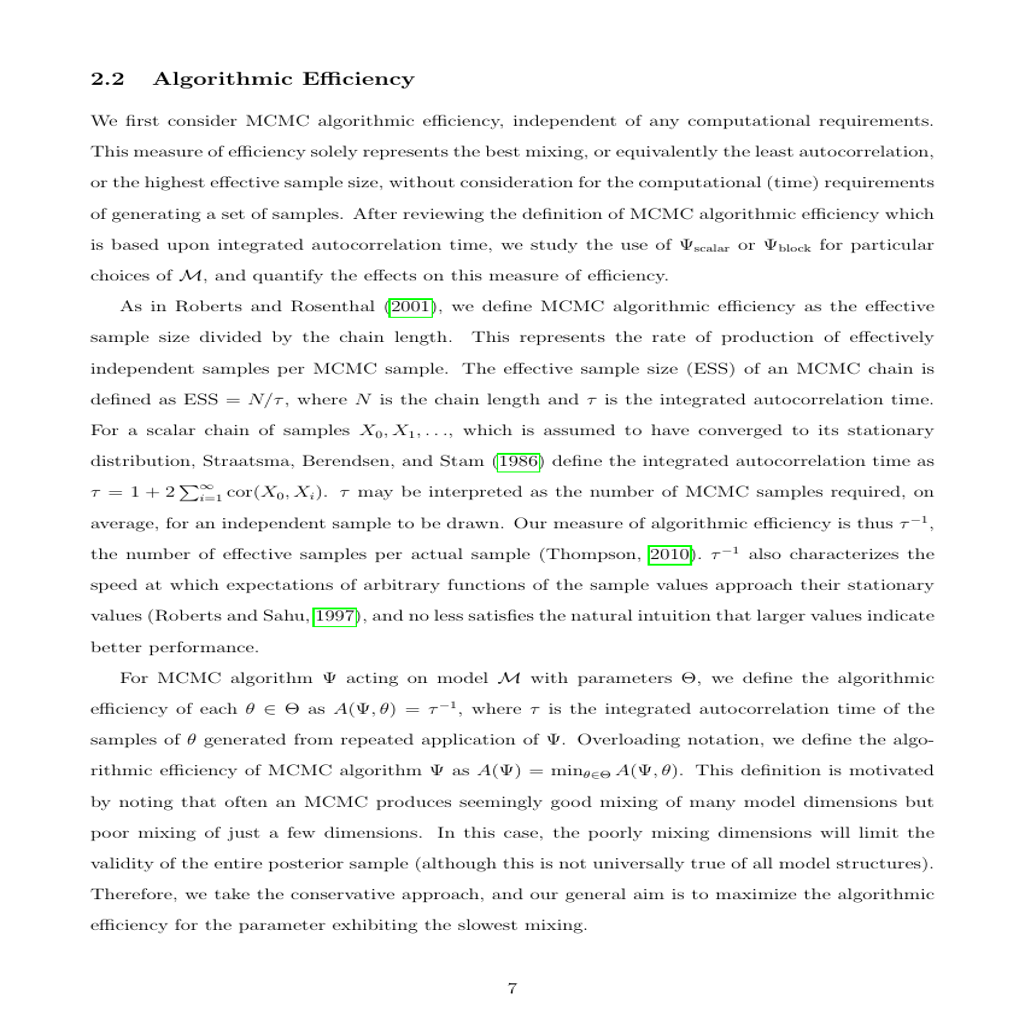

In [22]:
import random
from PIL import Image as PILImage
from src.utils import logits_to_multiclass_mask

png_path = DATA_PATH / SUBSET_DATANAME / "PNG"
all_data_paths = list(png_path.glob("*.png"))
random_image_path = random.sample(all_data_paths, k=1)[0]

sample_image = PILImage.open(random_image_path)
print(f"[INFO] Prediction on image at path: {random_image_path}")
sample_image

In [23]:
from typing import Tuple


def predict_semantic(img: PILImage.Image) -> Tuple[torch.Tensor, torch.Tensor]:
    """Run the semantic model on a PIL image.

    Returns:
        img_logits: (1, NUM_CLASSES, H, W) raw logits.
        img_mask:   (H, W) integer class-index tensor.
    """
    semantic_model.eval()
    img_t = inference_transform(img).unsqueeze(0)  # (1, 3, H, W)
    with torch.inference_mode():
        img_logits = semantic_model(img_t)          # (1, NUM_CLASSES, H, W)
        img_mask   = logits_to_multiclass_mask(img_logits)  # (1, H, W)
    return img_logits, img_mask


img_logits, img_mask = predict_semantic(img=sample_image)
print(f"Logits shape: {img_logits.shape}")
print(f"Mask shape:   {img_mask.shape}")
print(f"Unique predicted classes: {img_mask.unique().tolist()}")

Logits shape: torch.Size([1, 12, 512, 512])
Mask shape:   torch.Size([1, 512, 512])
Unique predicted classes: [0, 5, 8, 10]


## 7. Gradio demo

In [ ]:
import gradio as gr
import numpy as np
import torch
from collections import defaultdict
from PIL import Image as PILImage

from src.utils import get_semantic_metrics, get_soft_metrics, logits_to_multiclass_mask

# ── helpers ──────────────────────────────────────────────────────────────────

def _preprocess(image: PILImage.Image) -> torch.Tensor:
    """Normalised tensor ready for the model: (1, 3, H, W)."""
    return inference_transform(image).unsqueeze(0)


def _predict(image_tensor: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """Forward pass; returns raw logits and argmax class-index mask."""
    semantic_model.eval()
    with torch.inference_mode():
        logits = semantic_model(image_tensor)       # (1, NUM_CLASSES, H, W)
        mask   = logits_to_multiclass_mask(logits)  # (1, H, W)
    return logits, mask


def _mask_to_png_array(mask: torch.Tensor) -> np.ndarray:
    """Convert a (1, H, W) or (H, W) integer mask to a colour-coded uint8 RGB array."""
    mask_hw = mask.squeeze().cpu().numpy().astype(np.int32)
    rgb = (apply_colormap(mask_hw, COLOR_LUT) * 255).clip(0, 255).astype(np.uint8)
    return rgb


def _overlay_mask(image: PILImage.Image, mask: torch.Tensor, alpha: float = 0.45) -> np.ndarray:
    """Blend the colour-coded semantic mask on top of the original image."""
    img_t  = api_transform(image)
    img_np = img_t.permute(1, 2, 0).numpy()
    mask_rgb = _mask_to_png_array(mask).astype(np.float32) / 255.0
    overlay  = (1 - alpha) * img_np + alpha * mask_rgb
    return (overlay.clip(0, 1) * 255).astype(np.uint8)


# ── main inference function ───────────────────────────────────────────────────

def inference(image: PILImage.Image, gt_mask: PILImage.Image = None):
    # --- Prediction ---------------------------------------------------------
    image_tensor = _preprocess(image)
    logits, pred_mask = _predict(image_tensor)

    pred_mask_png = _mask_to_png_array(pred_mask)
    overlay       = _overlay_mask(image, pred_mask)

    # --- Metrics (optional) -------------------------------------------------
    if gt_mask is None:
        return pred_mask_png, overlay, "No ground truth provided → metrics unavailable"

    gt_pil_resized = gt_mask.resize((new_width, new_height))

    if gt_pil_resized.mode in ("L", "P"):
        gt_np = np.array(gt_pil_resized.convert("L"), dtype=np.int64)
    else:
        gt_rgb = np.array(gt_pil_resized.convert("RGB"), dtype=np.float32) / 255.0
        lut    = COLOR_LUT
        dists  = np.linalg.norm(
            gt_rgb[:, :, np.newaxis, :] - lut[np.newaxis, np.newaxis, :, :],
            axis=-1
        )
        gt_np = np.argmin(dists, axis=-1).astype(np.int64)

    gt_tensor = torch.from_numpy(gt_np).unsqueeze(0)  # (1, H, W)

    hard_metrics = get_semantic_metrics(
        logits, gt_tensor,
        num_classes=NUM_CLASSES,
        ignore_background=True,
        reduction="macro",
    )
    soft_metrics = get_soft_metrics(
        logits, gt_tensor,
        is_binary=False,
        ignore_background=True,
    )

    total_metrics: Dict[str, list] = defaultdict(list)
    for k, v in hard_metrics.items():
        total_metrics[k].append(float(v))
    for k, v in soft_metrics.items():
        val = v.item() if isinstance(v, torch.Tensor) else float(v)
        total_metrics[k].append(val)

    lines = ["=== Hard Pixel Metrics (macro, ignore bg) ==="]
    for k in ["precision", "recall", "f1_score", "iou_pixel", "dice_pixel"]:
        if k in total_metrics:
            lines.append(f"  {k:<16s}: {total_metrics[k][0]:.4f}")
    lines.append("")
    lines.append("=== Soft Region Metrics ===")
    for k in ["IoU_region", "DsC_region"]:
        if k in total_metrics:
            lines.append(f"  {k:<16s}: {total_metrics[k][0]:.4f}")
    lines.append("")
    lines.append("=== Per-class Soft IoU ===")
    for c in range(1, NUM_CLASSES):
        key = f"IoU_class_{c}"
        if key in total_metrics:
            val  = total_metrics[key][0]
            name = CLASS_ID_TO_NAME.get(c, str(c))
            lines.append(f"  [{c:2d}] {name:<16s}: {val:.4f}")

    return pred_mask_png, overlay, "\n".join(lines)


# ── Gradio interface ──────────────────────────────────────────────────────────

EXAMPLES_DIR = working_path / "examples"

demo = gr.Interface(
    fn=inference,
    inputs=[
        gr.Image(type="pil", label="Input Image"),
        gr.Image(type="pil", label="Ground Truth Semantic Mask (optional)"),
    ],
    outputs=[
        gr.Image(label="Predicted Semantic Mask"),
        gr.Image(label="Overlay"),
        gr.Textbox(label="Metrics"),
    ],
    title="LinkNet Semantic Segmentation — DocLayNet ChestNut 🌰",
    description=(
        "Upload a document image to obtain its 12-class semantic segmentation mask. "
        "Optionally upload a ground-truth mask (colour-coded PNG or greyscale class-index PNG) "
        "to compute hard pixel and soft region metrics."
    ),
    examples=[
        [str(EXAMPLES_DIR / "semantic_1_img.png"), str(EXAMPLES_DIR / "semantic_1_semantic_mask.png")],
        [str(EXAMPLES_DIR / "semantic_2_img.png"), str(EXAMPLES_DIR / "semantic_2_semantic_mask.png")],
        [str(EXAMPLES_DIR / "semantic_3_img.png"), str(EXAMPLES_DIR / "semantic_3_semantic_mask.png")],
    ],
)

demo.launch(debug=False, share=True, allowed_paths = [str(EXAMPLES_DIR)])

* Running on local URL:  http://127.0.0.1:7867
* Running on public URL: https://5a53f1cd950c6917cd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
